# Day_22_Task Sheet_Logistic Regression from Scratch & Classification Metrics · Titanic Dataset

### Part A — The Classification Setup

### TASK 01 · Encode, split, and standardize

In [61]:

# --------------------------------------------------
# TASK 01: Encode, Split, and Standardize
# --------------------------------------------------

# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# --------------------------------------------------
# 2. Load the Titanic dataset
# --------------------------------------------------

df = pd.read_csv("titanic.csv")

print("Dataset Shape:", df.shape)
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# --------------------------------------------------
# 3. Encode the Sex column
# --------------------------------------------------

# Female = 1 and Male = 0
df["Sex"] = (df["Sex"].str.lower() == "female").astype(int)

print("\nSex Encoding:")
print(df["Sex"].value_counts())


# --------------------------------------------------
# 4. Separate features and target
# --------------------------------------------------

# X contains independent variables
# y contains the binary target variable
X = df.drop(columns=["Survived"])
y = df["Survived"].to_numpy()

print("\nFeatures:")
display(X.head())

print("\nTarget Distribution:")
print(pd.Series(y).value_counts())


# --------------------------------------------------
# 5. Check missing values
# --------------------------------------------------

# The uploaded dataset has no missing values.
# This check ensures that the data is ready for splitting.

print("\nTotal Missing Values:", X.isnull().sum().sum())


# --------------------------------------------------
# 6. Split into training and testing datasets
# --------------------------------------------------

# 80% training and 20% testing
# stratify=y maintains the target class proportions
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target:", y_train.shape)
print("Testing Target:", y_test.shape)


# --------------------------------------------------
# 7. Verify target distribution
# --------------------------------------------------

print("\nTraining Class Distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nTesting Class Distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


# --------------------------------------------------
# 8. Standardize the features
# --------------------------------------------------

scaler = StandardScaler()

# Fit scaler ONLY on training data
# This prevents data leakage from the test dataset
X_tr = scaler.fit_transform(X_train)

# Apply the same scaler to testing data
X_te = scaler.transform(X_test)


# --------------------------------------------------
# 9. Verify standardization
# --------------------------------------------------

scaling_summary = pd.DataFrame({
    "Feature": X.columns,
    "Mean": X_tr.mean(axis=0),
    "Standard Deviation": X_tr.std(axis=0)
})

print("\nScaling Verification:")
display(scaling_summary.round(4))

print(
    "Training Mean Approximately Zero:",
    np.allclose(X_tr.mean(axis=0), 0, atol=1e-6)
)

print(
    "Training Standard Deviation Approximately One:",
    np.allclose(X_tr.std(axis=0), 1, atol=1e-6)
)


# --------------------------------------------------
# 10. Final verification
# --------------------------------------------------

print("\nFinal Verification:")

print("Binary Target:", set(np.unique(y)) == {0, 1})
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("Training Data Shape:", X_tr.shape)
print("Testing Data Shape:", X_te.shape)

print("\nTASK 01 Completed Successfully!")

Dataset Shape: (1000, 7)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,2,female,17.8,0,0,23.94
1,0,3,male,18.5,1,0,29.07
2,0,3,male,26.6,1,0,17.63
3,0,3,male,34.7,0,2,13.72
4,1,1,male,42.0,0,0,128.90



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1000 non-null   int64  
 1   Pclass    1000 non-null   int64  
 2   Sex       1000 non-null   str    
 3   Age       1000 non-null   float64
 4   SibSp     1000 non-null   int64  
 5   Parch     1000 non-null   int64  
 6   Fare      1000 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 54.8 KB

Missing Values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

Sex Encoding:
Sex
0    660
1    340
Name: count, dtype: int64

Features:


,Pclass,Sex,Age,SibSp,Parch,Fare
0,2,1,17.8,0,0,23.94
1,3,0,18.5,1,0,29.07
2,3,0,26.6,1,0,17.63
3,3,0,34.7,0,2,13.72
4,1,0,42.0,0,0,128.90



Target Distribution:
0    560
1    440
Name: count, dtype: int64

Total Missing Values: 0

Training Features: (800, 6)
Testing Features: (200, 6)

Training Target: (800,)
Testing Target: (200,)

Training Class Distribution:
0    0.56
1    0.44
Name: proportion, dtype: float64

Testing Class Distribution:
0    0.56
1    0.44
Name: proportion, dtype: float64

Scaling Verification:


,Feature,Mean,Standard Deviation
0,Pclass,-0.0,1.0
1,Sex,-0.0,1.0
2,Age,0.0,1.0
3,SibSp,-0.0,1.0
4,Parch,0.0,1.0
5,Fare,0.0,1.0


Training Mean Approximately Zero: True
Training Standard Deviation Approximately One: True

Final Verification:
Binary Target: True
Training Samples: 800
Testing Samples: 200
Training Data Shape: (800, 6)
Testing Data Shape: (200, 6)

TASK 01 Completed Successfully!


### Research Questions — TASK 01: Logistic Regression

1. Why is stratified splitting essential in classification?

    Stratified splitting maintains the same proportion of each target class in both training and testing datasets. It helps ensure fair model training and reliable evaluation, especially when classes are imbalanced.

2. What exact data leakage occurs if test data is scaled together with training data?

    When scaling the entire dataset before splitting, the scaler learns the test data's mean and standard deviation. This allows information from unseen test data to influence training preprocessing, resulting in data leakage and potentially misleading evaluation results.

### Key Takeaway

Stratification preserves class balance, while fitting the scaler only on training data prevents test information from influencing model preparation.


### Part B — Build and Prove (The Core Deliverable)

### TASK 02 · The Sigmoid function and Log-Loss

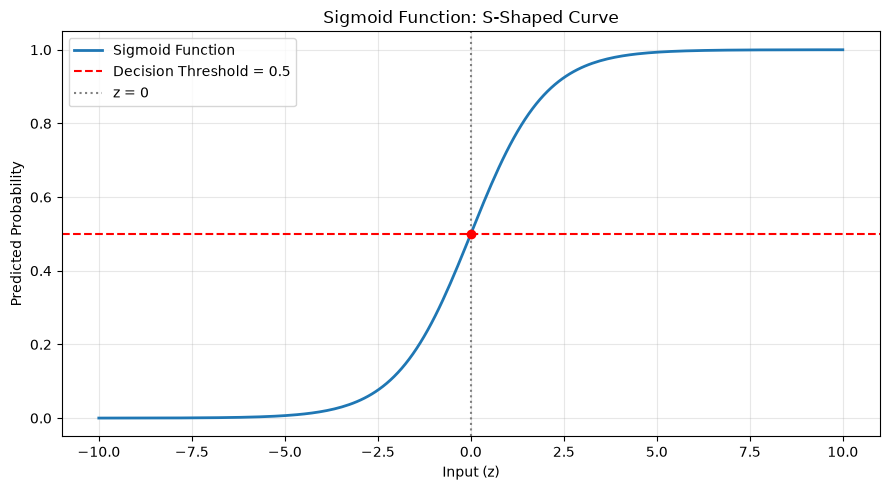

Binary Cross-Entropy Calculation

Actual Value: 1

Case 1: Predicted Probability = 0.90
Log-Loss = 0.1054

Case 2: Predicted Probability = 0.05
Log-Loss = 2.9957

Comparison:
Correct Prediction Loss: 0.1054
Incorrect Prediction Loss: 2.9957

Correct confident predictions receive lower penalties.


In [62]:

# --------------------------------------------------
# TASK 02: Sigmoid Function and Binary Cross-Entropy
# --------------------------------------------------

# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 2. Define vectorized sigmoid function
# --------------------------------------------------

def sigmoid(z):
    """
    Convert numerical values into probabilities
    between 0 and 1.

    Formula:
    sigmoid(z) = 1 / (1 + exp(-z))
    """

    return 1 / (1 + np.exp(-z))


# --------------------------------------------------
# 3. Generate input values
# --------------------------------------------------

# Generate 200 equally spaced values from -10 to +10
z = np.linspace(-10, 10, 200)

# Calculate sigmoid probabilities
probabilities = sigmoid(z)


# --------------------------------------------------
# 4. Plot sigmoid S-curve
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    z,
    probabilities,
    linewidth=2,
    label="Sigmoid Function"
)

# Highlight probability threshold = 0.5
plt.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    label="Decision Threshold = 0.5"
)

# Highlight z = 0
plt.axvline(
    x=0,
    color="gray",
    linestyle=":",
    label="z = 0"
)

# Highlight the intersection point
plt.scatter(0, 0.5, color="red", zorder=5)

plt.title("Sigmoid Function: S-Shaped Curve")
plt.xlabel("Input (z)")
plt.ylabel("Predicted Probability")

plt.ylim(-0.05, 1.05)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. Define Binary Cross-Entropy
# --------------------------------------------------

def binary_cross_entropy(y, p):
    """
    Calculate Binary Cross-Entropy loss.

    y = Actual class (0 or 1)
    p = Predicted probability

    Formula:
    Loss = -[y*log(p) + (1-y)*log(1-p)]
    """

    # Prevent logarithm of zero
    p = np.clip(p, 1e-15, 1 - 1e-15)

    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


# --------------------------------------------------
# 6. Calculate Log-Loss manually
# --------------------------------------------------

# Actual class = 1 (Survived)
actual = 1

# Case 1: Correct prediction
probability_1 = 0.90

# Case 2: Incorrect prediction
probability_2 = 0.05

loss_1 = binary_cross_entropy(actual, probability_1)
loss_2 = binary_cross_entropy(actual, probability_2)


# --------------------------------------------------
# 7. Display results
# --------------------------------------------------

print("Binary Cross-Entropy Calculation")

print("\nActual Value:", actual)

print("\nCase 1: Predicted Probability = 0.90")
print(f"Log-Loss = {loss_1:.4f}")

print("\nCase 2: Predicted Probability = 0.05")
print(f"Log-Loss = {loss_2:.4f}")


# --------------------------------------------------
# 8. Compare both predictions
# --------------------------------------------------

print("\nComparison:")

print(f"Correct Prediction Loss: {loss_1:.4f}")
print(f"Incorrect Prediction Loss: {loss_2:.4f}")

print(
    "\nCorrect confident predictions receive lower penalties."
)

### TASK 02 — Sigmoid Function and Log-Loss

**Sigmoid Function:** The sigmoid function converts any real-valued input into a probability between 0 and 1. A probability of 0.5 represents the standard decision threshold.

**Binary Cross-Entropy:** Log-Loss measures how accurately predicted probabilities match actual outcomes. For an actual value of 1, predicting 0.9 gives a loss of approximately 0.1054, while predicting 0.05 gives a much higher loss of approximately 2.9957.

**Conclusion:** Log-Loss strongly penalizes confident incorrect predictions and rewards confident correct predictions, making it suitable for logistic regression.


### TASK 03 · Method 1 — Logistic Regression from scratch

Logistic Regression trained successfully!

Learned Model Parameters:
Bias: -0.278049


,Feature,Weight
0,Pclass,-0.696504
1,Sex,1.166072
2,Age,-0.060972
3,SibSp,-0.212330
4,Parch,-0.043226
5,Fare,0.121743



Initial Training Loss: 0.684437
Final Training Loss: 0.5163


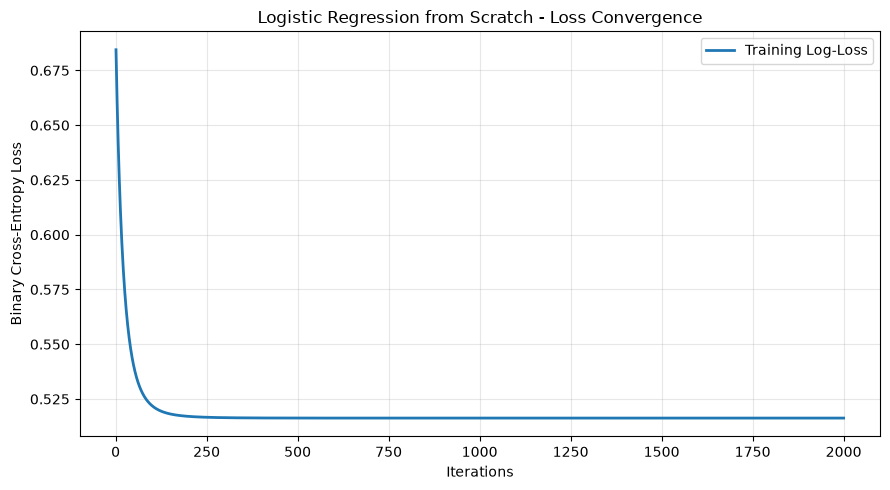


Convergence Verification:
Loss Decreased: True
Number of Increasing Loss Steps: 0
Final Loss: 0.516300

Prediction Verification:
Predictions Shape: (200,)
Unique Predicted Classes: [0 1]

TASK 03 Completed Successfully!


In [63]:

# --------------------------------------------------
# TASK 03: Logistic Regression from Scratch
# --------------------------------------------------

# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 2. Define Logistic Regression Class
# --------------------------------------------------

class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, n_iterations=2000):

        # Initialize hyperparameters
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        # Initialize model parameters
        self.w = None
        self.b = 0.0

        # Store training loss at each iteration
        self.loss_history = []


    # --------------------------------------------------
    # Calculate Binary Cross-Entropy Loss
    # --------------------------------------------------

    def compute_loss(self, y, p):

        # Avoid log(0) numerical errors
        p = np.clip(p, 1e-15, 1 - 1e-15)

        # Calculate average Binary Cross-Entropy
        loss = -np.mean(
            y * np.log(p) +
            (1 - y) * np.log(1 - p)
        )

        return loss


    # --------------------------------------------------
    # Train the model using Gradient Descent
    # --------------------------------------------------

    def fit(self, X, y):

        # Convert input data into NumPy arrays
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Number of samples and features
        m, n = X.shape

        # Initialize weights and bias
        self.w = np.zeros(n)
        self.b = 0.0

        # Clear previous training history
        self.loss_history = []

        # Gradient Descent
        for iteration in range(self.n_iterations):

            # Step 1: Calculate linear combination
            z = X @ self.w + self.b

            # Step 2: Calculate predicted probabilities
            p = sigmoid(z)

            # Step 3: Calculate prediction errors
            errors = p - y

            # Step 4: Calculate gradients
            dw = (X.T @ errors) / m
            db = np.mean(errors)

            # Step 5: Update weights and bias
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Step 6: Calculate updated probabilities
            updated_z = X @ self.w + self.b
            updated_p = sigmoid(updated_z)

            # Step 7: Calculate and store loss
            loss = self.compute_loss(y, updated_p)

            self.loss_history.append(loss)

        return self


    # --------------------------------------------------
    # Predict probabilities
    # --------------------------------------------------

    def predict_proba(self, X):

        X = np.asarray(X, dtype=float)

        # Calculate linear output
        z = X @ self.w + self.b

        # Return probability of class 1
        return sigmoid(z)


    # --------------------------------------------------
    # Predict class labels
    # --------------------------------------------------

    def predict(self, X):

        probabilities = self.predict_proba(X)

        # Apply 0.5 decision threshold
        return (probabilities >= 0.5).astype(int)


# --------------------------------------------------
# 3. Initialize and train the model
# --------------------------------------------------

scratch_model = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=2000
)

# Train using standardized training data
scratch_model.fit(X_tr, y_train)

print("Logistic Regression trained successfully!")


# --------------------------------------------------
# 4. Display learned parameters
# --------------------------------------------------

print("\nLearned Model Parameters:")

print(f"Bias: {scratch_model.b:.6f}")

weights = pd.DataFrame({
    "Feature": X.columns,
    "Weight": scratch_model.w
})

display(weights.round(6))


# --------------------------------------------------
# 5. Display training loss
# --------------------------------------------------

print(
    "\nInitial Training Loss:",
    round(scratch_model.loss_history[0], 6)
)

print(
    "Final Training Loss:",
    round(scratch_model.loss_history[-1], 6)
)


# --------------------------------------------------
# 6. Plot loss convergence
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, scratch_model.n_iterations + 1),
    scratch_model.loss_history,
    linewidth=2,
    label="Training Log-Loss"
)

plt.title("Logistic Regression from Scratch - Loss Convergence")
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 7. Verify loss convergence
# --------------------------------------------------

loss_differences = np.diff(scratch_model.loss_history)

print("\nConvergence Verification:")

print(
    "Loss Decreased:",
    scratch_model.loss_history[-1] <
    scratch_model.loss_history[0]
)

print(
    "Number of Increasing Loss Steps:",
    np.sum(loss_differences > 1e-10)
)

print(
    "Final Loss:",
    f"{scratch_model.loss_history[-1]:.6f}"
)


# --------------------------------------------------
# 8. Verify prediction methods
# --------------------------------------------------

scratch_predictions = scratch_model.predict(X_te)

print("\nPrediction Verification:")
print("Predictions Shape:", scratch_predictions.shape)
print("Unique Predicted Classes:", np.unique(scratch_predictions))

print("\nTASK 03 Completed Successfully!")

### TASK 03 — Logistic Regression from Scratch

Logistic Regression was implemented using NumPy and Gradient Descent. The model initializes weights and bias with zeros, calculates predicted probabilities using the sigmoid function, and updates parameters using the gradients of Binary Cross-Entropy loss.

The training loss is recorded over 2,000 iterations and visualized to observe convergence. A decreasing and flattening loss curve indicates that the model is learning and approaching a minimum of the loss function.

### Important observations

    Initial loss: Usually around 0.693 when starting with zero weights and balanced initial probabilities.

    Final loss: Should be lower than the initial loss.

    Loss curve: Should generally decrease and flatten.

    Monotonic convergence: The loss should not increase between iterations for a sufficiently small learning rate, but this is not guaranteed for every learning rate or dataset.

Key takeaway: This implementation demonstrates how logistic regression learns survival patterns by repeatedly adjusting weights and bias to minimize prediction error.

### TASK 04 · Method 2 — Scikit-Learn parity proof

In [64]:

# --------------------------------------------------
# TASK 04: Scikit-Learn Parity Proof
# --------------------------------------------------

# 1. Import necessary libraries
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression


# --------------------------------------------------
# 2. Train Scikit-Learn Logistic Regression
# --------------------------------------------------

# penalty=None means no regularization
# lbfgs is the optimization algorithm

sk_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=1000
)

# Train using the same standardized training dataset
sk_model.fit(X_tr, y_train)

print("Scikit-Learn model trained successfully!")


# --------------------------------------------------
# 3. Compare intercept and feature weights
# --------------------------------------------------

# Combine intercept and feature weights
scratch_parameters = np.concatenate((
    [scratch_model.b],
    scratch_model.w
))

sklearn_parameters = np.concatenate((
    sk_model.intercept_,
    sk_model.coef_[0]
))

# Create comparison DataFrame
parity_df = pd.DataFrame({

    "Feature": ["Intercept"] + list(X.columns),

    "Scratch": scratch_parameters,

    "Sklearn": sklearn_parameters

})

# Calculate absolute difference
parity_df["Absolute Difference"] = (
    parity_df["Scratch"] - parity_df["Sklearn"]
).abs()


print("\nWeight Comparison:")
display(parity_df.round(6))


# --------------------------------------------------
# 4. Verify numerical parity
# --------------------------------------------------

# Maximum difference between corresponding parameters
max_weight_difference = (
    parity_df["Absolute Difference"].max()
)

# Check whether all parameters match within 0.001
weights_match = np.allclose(
    scratch_parameters,
    sklearn_parameters,
    atol=1e-3,
    rtol=0
)

print("\nWeight Parity Verification:")

print(
    "Maximum Weight Difference:",
    f"{max_weight_difference:.8f}"
)

print(
    "All Weights Match Within 10^-3:",
    weights_match
)


# --------------------------------------------------
# 5. Compare predicted probabilities
# --------------------------------------------------

# Scratch model probabilities
scratch_probabilities = scratch_model.predict_proba(X_te)

# Scikit-Learn probabilities for class 1
sklearn_probabilities = sk_model.predict_proba(X_te)[:, 1]

# Calculate maximum probability difference
max_probability_difference = np.max(
    np.abs(
        scratch_probabilities - sklearn_probabilities
    )
)

print("\nProbability Comparison:")

print(
    "Maximum Probability Difference:",
    f"{max_probability_difference:.8f}"
)


# --------------------------------------------------
# 6. Compare test-set predictions
# --------------------------------------------------

# Predictions from both models
scratch_predictions = scratch_model.predict(X_te)

sklearn_predictions = sk_model.predict(X_te)

# Check whether predictions are identical
predictions_match = np.array_equal(
    scratch_predictions,
    sklearn_predictions
)

# Count different predictions
different_predictions = np.sum(
    scratch_predictions != sklearn_predictions
)

print("\nPrediction Comparison:")

print("Test Predictions Match:", predictions_match)

print(
    "Number of Different Predictions:",
    different_predictions
)


# --------------------------------------------------
# 7. Final parity verification
# --------------------------------------------------

print("\nFinal Parity Verification:")

print("Weight Difference < 0.001:",
      max_weight_difference < 1e-3)

print("Predictions Identical:",
      predictions_match)

if weights_match and predictions_match:

    print(
        "\nTASK 04 Completed Successfully!"
    )

else:

    print(
        "\nModels require further convergence checking."
    )

Scikit-Learn model trained successfully!

Weight Comparison:


c:\Users\MIHIR SOLANKI\miniconda3\envs\aiml\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Feature,Scratch,Sklearn,Absolute Difference
0,Intercept,-0.278049,-0.278052,0.000002
1,Pclass,-0.696504,-0.696723,0.000218
2,Sex,1.166072,1.166253,0.000181
3,Age,-0.060972,-0.061025,0.000054
4,SibSp,-0.212330,-0.212460,0.000129
5,Parch,-0.043226,-0.043259,0.000033
6,Fare,0.121743,0.121748,0.000005



Weight Parity Verification:
Maximum Weight Difference: 0.00021841
All Weights Match Within 10^-3: True

Probability Comparison:
Maximum Probability Difference: 0.00008989

Prediction Comparison:
Test Predictions Match: True
Number of Different Predictions: 0

Final Parity Verification:
Weight Difference < 0.001: True
Predictions Identical: True

TASK 04 Completed Successfully!


### Part C — Measure, Tune, and Interpret

### TASK 05 · Confusion Matrix and Classification Metrics

Test Prediction Generated Successfully!

Actual Values : 
[1 0 1 1 1 1 0 1 1 1]

Predicted Values : 
[1 0 1 0 1 0 0 1 1 1]

Confusion Matrix : 
[[86 26]
 [21 67]]

Confusion Matrix Values : 
True Negative (TN) :  86
False Positive (FP) :  26
False Negative (FN) :  21
True Positive (TP) :  67


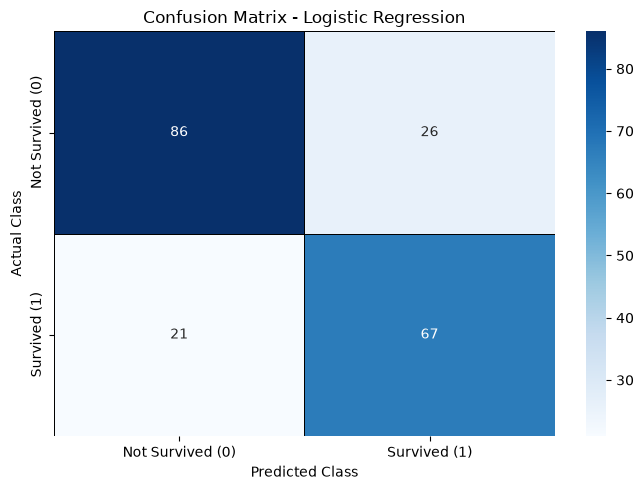


Classification Metrics : 


,Metric,Score
0,Accuracy,0.7650
1,Precision,0.7204
2,Recall,0.7614
3,F1-Score,0.7403


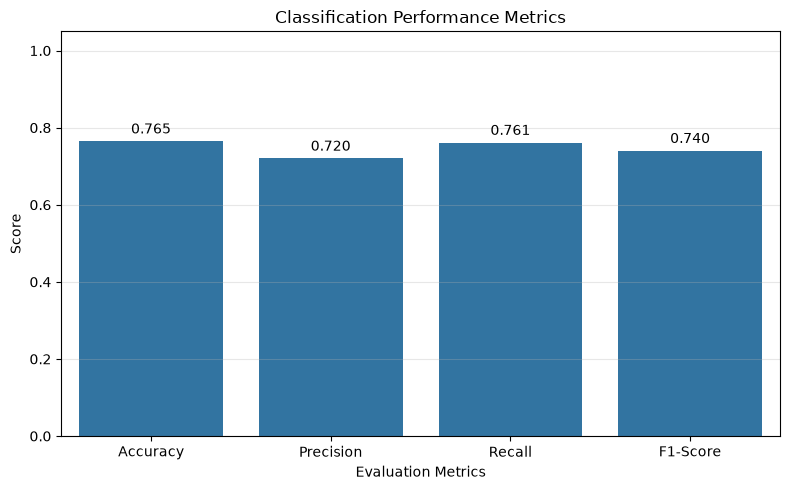


Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.77      0.79       112
    Survived       0.72      0.76      0.74        88

    accuracy                           0.77       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.77      0.77      0.77       200


TASK 05 Final Verification:
Total Test Samples: 200
Total Correct Predictions: 153
Total Incorrect Predictions: 47
Confusion Matrix Shape: (2, 2)

TASK 05 Completed Successfully!


In [65]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# --------------------------------------------------
# 2. Generate predictions on test data
# --------------------------------------------------

# Use the Scikit-Learn model trained in TASK 04
# The model predicts whether a passenger survived or not

y_pred = sk_model.predict(X_te)

print("Test Prediction Generated Successfully!")

print("\nActual Values : ")
print(y_test[:10])

print("\nPredicted Values : ")
print(y_pred[:10])

# --------------------------------------------------
# 3. Calculate Confusion Matrix
# --------------------------------------------------

# Confusion Matrix format:
#
#                  Predicted
#                 0       1
# Actual  0       TN      FP
#         1       FN      TP
#
# 0 = Did not survive
# 1 = Survived

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix : ")
print(cm)

# --------------------------------------------------
# 4. Extract TP, FP, TN, and FN
# --------------------------------------------------

# Extract individual values from the confusion matrix
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Values : ")

print("True Negative (TN) : ", tn)
print("False Positive (FP) : ", fp)
print("False Negative (FN) : ", fn)
print("True Positive (TP) : ", tp)


# --------------------------------------------------
# 5. Plot Confusion Matrix Heatmap
# --------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,             # Display values inside cells
    fmt="d",                # Display integer values
    cmap="Blues",           # Heatmap color
    linewidths=0.5,
    linecolor="black",
    xticklabels=["Not Survived (0)", "Survived (1)"],
    yticklabels=["Not Survived (0)", "Survived (1)"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Calculate Classification Metrics
# --------------------------------------------------

# Accuracy: Overall percentage of correct predictions
accuracy = accuracy_score(
    y_test,
    y_pred
)

# Precision: Correct positive predictions / Total predicted positives
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)    

# Recall: Percentage of actual survivors correctly identified
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

# F1-Score: Harmonic mean of Precision and Recall
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)    

# --------------------------------------------------
# 7. Display Classification Metrics
# --------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric" : [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    
    "Score" : [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\nClassification Metrics : ")
display(metrics_df.round(4))

# --------------------------------------------------
# 8. Visualize Classification Metrics
# --------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score"
)

plt.title("Classification Performance Metrics")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)

# Display metric values above each bar
for index, value in enumerate(metrics_df["Score"]):
    plt.text(
        index,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 9. Classification Report
# --------------------------------------------------

# Provides precision, recall, F1-score, and support
# separately for each target class

print("\nDetailed Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Survived", "Survived"],
        zero_division=0
    )
)


# --------------------------------------------------
# 10. Final Verification
# --------------------------------------------------

print("\nTASK 05 Final Verification:")

print("Total Test Samples:", len(y_test))
print("Total Correct Predictions:", tp + tn)
print("Total Incorrect Predictions:", fp + fn)

print("Confusion Matrix Shape:", cm.shape)

print("\nTASK 05 Completed Successfully!")

### TASK 06 · Decision Threshold Tuning and the ROC-AUC Curve

Predicted Probabilities:
[0.91276928 0.29253588 0.94121233 0.12679747 0.80238844 0.30848975
 0.17331034 0.95489006 0.70668339 0.51299076]

Total Predictions: 200

Precision and Recall at Different Thresholds:


,Threshold,Precision,Recall
0,0.2,0.6183,0.9205
1,0.5,0.7204,0.7614
2,0.8,1.0000,0.3750


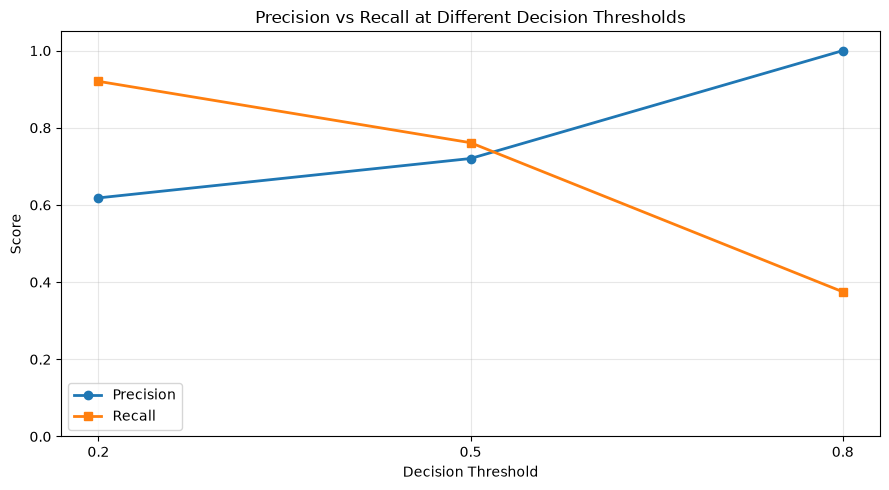


ROC-AUC Score: 0.8643


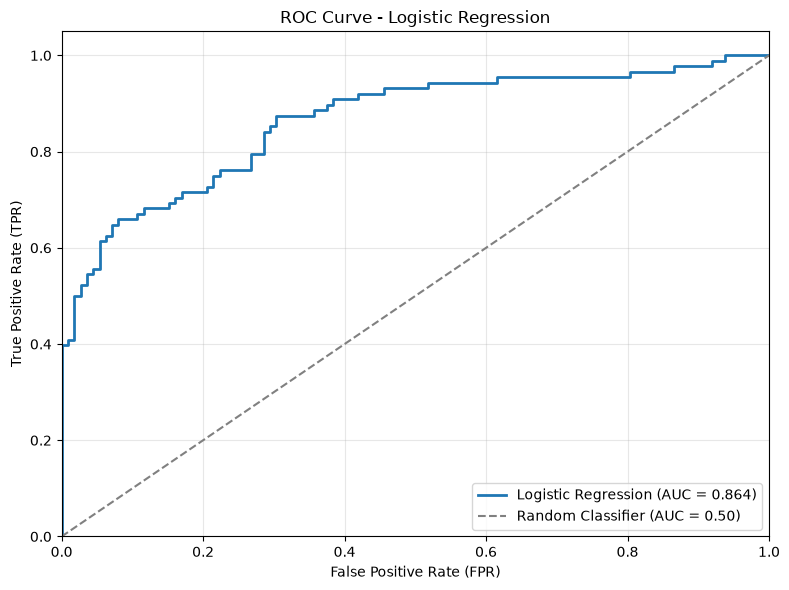


ROC Curve Data:


,False Positive Rate,True Positive Rate,Threshold
0,0.0000,0.0000,inf
1,0.0000,0.0114,0.9549
2,0.0000,0.3977,0.7771
3,0.0089,0.3977,0.7145
4,0.0089,0.4091,0.7107
5,0.0179,0.4091,0.7089
6,0.0179,0.5000,0.6940
7,0.0268,0.5000,0.6927
8,0.0268,0.5227,0.6914
9,0.0357,0.5227,0.6902



TASK 06 Final Verification:
Probability Array Shape: (200,)
Thresholds Tested: [0.2, 0.5, 0.8]
ROC-AUC: 0.8643
ROC Curve Points: 68

TASK 06 Completed Successfully!


In [66]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)


# --------------------------------------------------
# 2. Extract predicted probabilities
# --------------------------------------------------

# Get the probability of class 1 (Survived)
# Column 1 represents the probability of survival

probs = sk_model.predict_proba(X_te)[:, 1]

print("Predicted Probabilities:")
print(probs[:10])

print("\nTotal Predictions:", len(probs))


# --------------------------------------------------
# 3. Define decision thresholds
# --------------------------------------------------

# A threshold determines when a passenger is classified
# as survived (1) or not survived (0).

thresholds = [0.2, 0.5, 0.8]


# --------------------------------------------------
# 4. Calculate Precision and Recall
#    for different thresholds
# --------------------------------------------------

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into binary predictions
    # Probability >= threshold means class 1
    y_pred_threshold = (probs >= threshold).astype(int)

    # Calculate Precision
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    # Calculate Recall
    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    # Store results
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })


# --------------------------------------------------
# 5. Display threshold comparison
# --------------------------------------------------

threshold_df = pd.DataFrame(threshold_results)

print("\nPrecision and Recall at Different Thresholds:")

display(threshold_df.round(4))


# --------------------------------------------------
# 6. Plot Precision and Recall comparison
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

plt.title("Precision vs Recall at Different Decision Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.xticks(thresholds)
plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 7. Calculate ROC Curve
# --------------------------------------------------

# ROC Curve evaluates model performance across
# all possible classification thresholds.

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    probs
)

# Calculate Area Under the ROC Curve
roc_auc = roc_auc_score(
    y_test,
    probs
)

print("\nROC-AUC Score:", round(roc_auc, 4))


# --------------------------------------------------
# 8. Plot ROC Curve
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot the model ROC curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Plot random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier (AUC = 0.50)"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 9. Display ROC Curve values
# --------------------------------------------------

roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Threshold": roc_thresholds
})

print("\nROC Curve Data:")
display(roc_df.head(10).round(4))


# --------------------------------------------------
# 10. Final Verification
# --------------------------------------------------

print("\nTASK 06 Final Verification:")

print("Probability Array Shape:", probs.shape)

print("Thresholds Tested:", thresholds)

print("ROC-AUC:", round(roc_auc, 4))

print("ROC Curve Points:", len(fpr))

print("\nTASK 06 Completed Successfully!")

# TASK 06: Threshold Tuning and ROC Curve

## 1. Threshold Tuning

The default classification threshold is 0.5. We can change it to see how it affects precision and recall.

- **Lower threshold (0.2):** More passengers may be predicted as survivors, which can increase recall but may reduce precision.
- **Default threshold (0.5):** Provides a standard balance between precision and recall.
- **Higher threshold (0.8):** Fewer passengers may be predicted as survivors, which can increase precision but may reduce recall.

The actual results depend on the model and dataset.

## 2. ROC Curve and AUC

The ROC curve shows how the True Positive Rate (Recall) changes against the False Positive Rate at different thresholds.

- **ROC-AUC** measures how well the model distinguishes between the two classes.
- AUC closer to 1 indicates stronger class separation.
- AUC around 0.5 indicates performance similar to random guessing.

## 3. Business Interpretation

Threshold selection depends on the problem:

- In medical screening, recall may be more important because missing a positive case can be costly.
- In other situations, precision may be more important to reduce false alarms.
- The threshold should be selected based on the cost of false positives and false negatives.

## 4. Conclusion

Threshold tuning helps us understand the trade-off between precision and recall. The ROC curve and AUC provide an overall view of the model's ability to distinguish between classes across different thresholds.

### TASK 07 · Odds Ratios and Plain-English Model Interpretation

,Feature,Weight,Odds_Ratio
0,Pclass,-0.6967,0.4982
3,SibSp,-0.2125,0.8086
2,Age,-0.0610,0.9408
4,Parch,-0.0433,0.9577
5,Fare,0.1217,1.1295
1,Sex,1.1663,3.2099


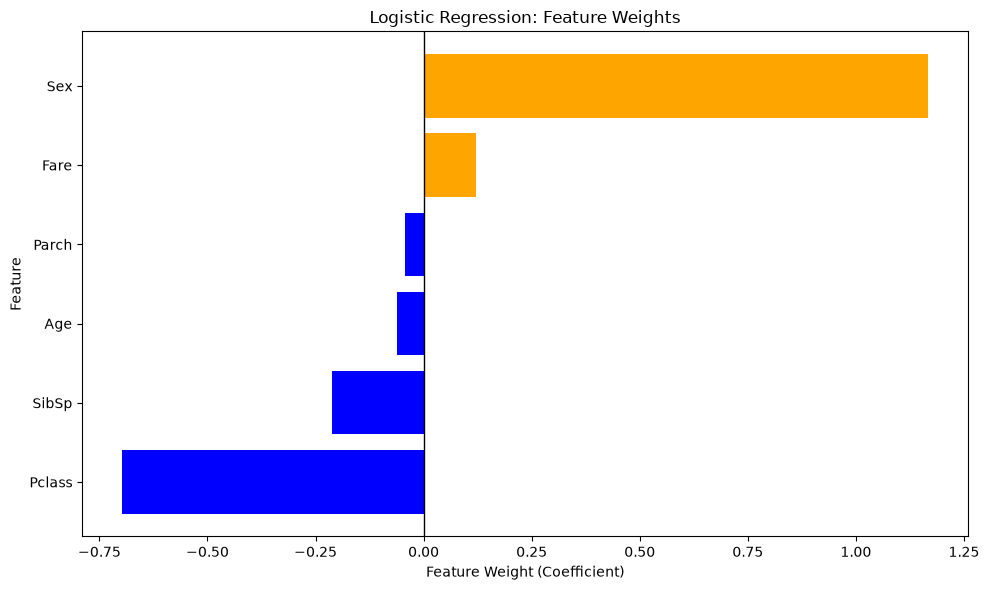

Odds Ratio Interpretation:
Pclass: A one-unit increase is associated with 50.18% lower odds of survival.
SibSp: A one-unit increase is associated with 19.14% lower odds of survival.
Age: A one-unit increase is associated with 5.92% lower odds of survival.
Parch: A one-unit increase is associated with 4.23% lower odds of survival.
Fare: A one-unit increase is associated with 12.95% higher odds of survival.
Sex: A one-unit increase is associated with 220.99% higher odds of survival.


In [67]:
# --------------------------------------------------
# TASK 07: Odds Ratios and Model Interpretation
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Extract feature names and model weights
# --------------------------------------------------

# X_tr is a NumPy array, so use the original X DataFrame
# to get the feature names in their original order
feature_names = X.columns

# Extract coefficients from the trained Scikit-Learn model
weights = sk_model.coef_[0]

# Create a DataFrame of feature weights
odds_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": weights
})

# --------------------------------------------------
# 2. Calculate Odds Ratios
# --------------------------------------------------

# Odds Ratio = e^(weight)
odds_df["Odds_Ratio"] = np.exp(odds_df["Weight"])

# Sort features by their weights
odds_df = odds_df.sort_values(
    by="Weight",
    ascending=True
)

# Display the results
display(odds_df.round(4))

# --------------------------------------------------
# 3. Plot feature weights
# --------------------------------------------------

# Orange = positive coefficient
# Blue = negative coefficient
bar_colors = [
    "orange" if weight > 0 else "blue"
    for weight in odds_df["Weight"]
]

plt.figure(figsize=(10, 6))

plt.barh(
    odds_df["Feature"],
    odds_df["Weight"],
    color=bar_colors
)

# Add zero reference line
plt.axvline(x=0, color="black", linewidth=1)

plt.title("Logistic Regression: Feature Weights")
plt.xlabel("Feature Weight (Coefficient)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Interpret Odds Ratios
# --------------------------------------------------

print("Odds Ratio Interpretation:")

for _, row in odds_df.iterrows():

    feature = row["Feature"]
    odds_ratio = row["Odds_Ratio"]

    if odds_ratio > 1:
        print(
            f"{feature}: A one-unit increase is associated with "
            f"{(odds_ratio - 1) * 100:.2f}% higher odds of survival."
        )

    elif odds_ratio < 1:
        print(
            f"{feature}: A one-unit increase is associated with "
            f"{(1 - odds_ratio) * 100:.2f}% lower odds of survival."
        )

    else:
        print(f"{feature}: No change in survival odds.")